
## Práctica 1: Exploración de Niveles del lenguaje 🔭

### FECHA DE ENTREGA: 10 de Marzo 2026 at 11:59pm



### Fonética

1. Con base en el sistema de búsqueda visto en la práctica 1, dónde se recibe una palabra ortográfica y devuelve sus transcripciones fonológicas, proponga una solución para los casos en que la palabra buscada no se encuentra en el lexicón/diccionario.
    - ¿Cómo devolver o **aproximar** su transcripción fonológica?
    - Reutiliza el sistema de búsqueda visto en clase y mejóralo con esta funcionalidad.
    - Muestra al menos tres ejemplos


Reciclando el procedimiento de la práctica 1, importamos algunos modulos necesarios y obtenemos el corpus.


In [ ]:
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import requests as r
from nltk.corpus import cess_esp

from rich import print as rprint

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import CRF



Tomamos los datos desde open-dict.

In [ ]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"


Definimos nuestros codigos de lenguaje para obtener el dataset.

In [ ]:
lang_codes = {
    "ar": "Arabic (Modern Standard)",
    "de": "German",
    "en_UK": "English (Received Pronunciation)",
    "en_US": "English (General American)",
    "eo": "Esperanto",
    "es_ES": "Spanish (Spain)",
    "es_MX": "Spanish (Mexico)",
    "fa": "Persian",
    "fi": "Finnish",
    "fr_FR": "French (France)",
    "fr_QC": "French (Québec)",
    "is": "Icelandic",
    "ja": "Japanese",
    "jam": "Jamaican Creole",
    "km": "Khmer",
    "ko": "Korean",
    "ma": "Malay (Malaysian and Indonesian)",
    "nb": "Norwegian Bokmål",
    "nl": "Dutch",
    "or": "Odia",
    "ro": "Romanian",
    "sv": "Swedish",
    "sw": "Swahili",
    "tts": "Isan",
    "vi_C": "Vietnamese (Central)",
    "vi_N": "Vietnamese (Northern)",
    "vi_S": "Vietnamese (Southern)",
    "yue": "Cantonese",
    "zh_hans": "Mandarin (Simplified)",
    "zh_hant": "Mandarin (Traditional)"
    }
iso_lang_codes = list(lang_codes.keys())

Reutilizamos el codigo para obtener el dataset y descargamos:


In [ ]:
def download_ipa_corpus(iso_lang: str) -> str:
    """Get ipa-dict file from Github

    Parameters:
    -----------
    iso_lang:
        Language as iso code

    Results:
    --------
    dict:
        Dictionary with words as keys and phonetic representation
        as values for a given lang code
    """
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

In [ ]:
def parse_response(response: str) -> dict:
    """Parse text response from ipa-dict to python dict

    Each row have the format:
    [WORD][TAB]/[IPA]/(, /[IPA]/)?

    Parameters
    ----------
    response: str
        ipa-dict raw text

    Returns
    -------
    dict:
        A dictionary with the word as key and the phonetic
        representations as value
    """
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result

In [ ]:
def get_corpora() -> dict:
    """Download corpora from ipa-dict github

    Given a list of iso lang codes download available datasets.

    Returns
    -------
    dict
        Lang codes as keys and dictionary with words-transcriptions
        as values
    """
    return {
        code: parse_response(download_ipa_corpus(code))
         for code in iso_lang_codes
    }

In [ ]:
corpora = get_corpora()

NameError: name 'http' is not defined

In [ ]:
def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict

    Given a word this function return the IPA transcriptions

    Parameters:
    -----------
    word: str
        A word to search in the dataset
    dataset: dict
        A dataset for a given language code

    Returns
    -------
    list[str]:
        List with posible transcriptions if any,
        else an empty list
    """
    return dataset.get(word.lower(), "").split(", ")

Teníamos entonces el siguiente sistema naive para devolver la transcripción fonologica a partir de una palabra ortogáfica.

In [ ]:
def get_formated_string(code: str, name: str):
    return f"[b]{name}[/b]\n[yellow]{code}"

In [ ]:
rprint(
    Panel(Text("Representación fonética de palabras", style="bold", justify="center"))
)
rendable_langs = [
    Panel(get_formated_string(code, lang), expand=True)
    for code, lang in lang_codes.items()
]
rprint(Columns(rendable_langs))

lang = input("lang>> ")
rprint(f"Selected language: {lang_codes[lang]}") if lang else rprint("Adios 👋🏼")
while lang:
    dataset = corpora[lang]
    query = input(f"  [{lang}]word>> ")
    results = get_ipa_transcriptions(query, dataset)
    print(query, " | ", ", ".join(results))
    while query:
        query = input(f"  [{lang}]word>> ")
        if query:
            results = get_ipa_transcriptions(query, dataset)
            rprint(query, " | ", ", ".join(results))
    lang = input("lang>> ")
    rprint(f"Selected language: [yellow]{lang_codes[lang]}[/]") if lang else rprint(
        "Adios 👋🏼"
    )

Sin embargo, esta implementación fallaba cuando pediamos la representación fonetica de palabras que no estuvieran el el corpus. Esto tiene dos causas probables:




El corpus no contiene a la transcripción  de la que buscamos ni ninguna similar.

Por ejemplo, el sistema falla con palabras de otros idiomas(prestamo lingüistico) que han pasado por un proceso de hibridación, entonces el sistema para el lenguaje español es incapaz de encotrar palabras como _parsear_,_twittear_,_postear_,etc.

En primera estancia este problema es complicado de resolver, pues el sistema busca exactamente la palabra que ingresamos y por el fenómeno del prestamo lingüistico no los encuentra, por lo tanto, pensaría en buscar un corpus que haya contemplado este fenómeno para agregarlo a nuestro dataset. Otra opción, pensando en el caso del español-inglés es implementar algún detector de idioma que detecte que la palabra ingresada es una combinación de una raiz extranjera y alguna estructura del español, de esta manera por ejemplo detectaría que _parsear_ se compone de _parse_ y la terminación del verbo en infinitivo _-ar_ y con ello haría la combinación de la transcripción lingüistica de parse en inglés y la terminación del infinitivo del español.

In [ ]:
# Biblioteca para expresiones regulares.
import re
def transcribir_hibrido_verbo_derivado_en_es(word: str) -> str:
    
    """
    Transcribe un verbo derivado del Ingles al Español a su forma híbrida en IPA.
    Por ejemplo, "parsear" se transcribiría como "/ˈpɑɹs/ 
    
    Parameters:    -----------
    word: str
        Verbo en infinitivo en español que se desea transcribir.
    Returns:
    --------
    str
        La transcipción fonológica híbrida del verbo, o None si no es un verbo derivado definido por la regex o la raiz no está en el corpus.
        """
    #Detecta que sea un verbo en infinitivo y devuelve su raíz.
    regex = r"^(.*?)(ar|er|ir|ando|ado)$"
    match = re.match(regex, word)
   

    if match:
        raiz = match.group(1)
        sufijo = match.group(2)
    
        dataset = corpora["en_US"]
        raiz_en = get_ipa_transcriptions(raiz, dataset)

        if raiz_en:
            raiz_en = raiz_en[0]
            if sufijo == "ar":
                return raiz_en + "ɐɾ"
            elif sufijo == "er":
                return raiz_en + "eɾ"
            elif sufijo == "ir":
                return raiz_en + "iɾ"
            elif sufijo =="ando":
                return raiz_en + "ɐndo"
            elif sufijo == "ado":
                return raiz_en + "aðo"
            elif sufijo == "":
                return raiz_en
        else:
            return None

    

In [ ]:
rprint(
      Panel(Text("Representación fonética de palabras", style="bold", justify="center"))
  )
rendable_langs = [
      Panel(get_formated_string(code, lang), expand=True)
      for code, lang in lang_codes.items()
  ]
rprint(Columns(rendable_langs))

lang = input("lang>> ")
rprint(f"Selected language: {lang_codes[lang]}") if lang else rprint("Adios 👋🏼")
while lang:
    dataset = corpora[lang]
    while True:
        query = input(f"  [{lang}]word>> ").strip()        
        if not query:
            break

        # 1. Intentamos buscar el dato en el corpus primero
        results = get_ipa_transcriptions(query, dataset)
        
        # Verificamos que el resultado sea válido y no esté vacío
        if results and results != ['']:
            rprint(f"[bold white]{query}[/] | [green]{', '.join(results)}[/] [italic](Corpus)[/]")
        
        else:
            # 2. En otro caso (si no está en el corpus), hacemos el análisis de palabra híbrida
            hybrid_vb = transcribir_hibrido_verbo_derivado_en_es(query)
            
            if hybrid_vb:
                rprint(f"[bold white]{query}[/] | [cyan]{hybrid_vb}[/] [italic](Análisis Híbrido)[/]")
            else:
                # 3. Si tampoco es híbrida, imprimimos el resultado vacio.
                rprint(query, " | ", ", ".join(results))
    lang = input("lang>> ").strip()
    if lang:
        rprint(f"Selected language: [yellow]{lang_codes.get(lang, lang)}[/]")
    else:
        rprint("Adios 👋🏼")

De cualquier manera, vemos que mi propuesta es un sistema bastante limitado, al estar basado en reglas muy basicas y solo tomar en cuenta los casos de anglisismos en el español, el programa es muy limitado. Es posible hacer un programa más complejo mediante aprendizaje de maquina en el que aprenda a leer estos fenómenos, sin embargo, creo que es muy complejo para el análisis de ésta práctica.

La palabra tiene algún error ortográfico.

Como la palabra está mal escrita es imposible que el sistema la encuentre, sin embargo, es posible dar una sugerencia de palabra que pueda ser similar a la que escribimos pero que si esté en el corpus, para ello, buscamos alguna palabra cuya distancia de Levenshtein, buscando en el corpus las palabras con la menor distancia de Levenshtein con respecto a la palabra que escribimos.


In [ ]:
from Levenshtein import distance as l_distance


In [ ]:
def dar_sugerencia_Levenshtein(word: str, dataset: dict, n: int = 5) -> [str]:
    """Dada una palabra y un dataset, devuelve la palabra más cercana
    según la distancia de Levenshtein.

    Parameters
    ----------
    word: str
        Palabra a comparar
    dataset: dict
        Dataset con palabras como claves

    Returns
    -------
    str
        La palabra más cercana en el dataset según Levenshtein.
    """
    return sorted(dataset.keys(), key=lambda x: l_distance(word, x))[:n]


De ésta manera, adjuntando esta solución al codigo de la clase tenemos que:


In [ ]:
rprint(
      Panel(Text("Representación fonética de palabras", style="bold", justify="center"))
  )
rendable_langs = [
      Panel(get_formated_string(code, lang), expand=True)
      for code, lang in lang_codes.items()
  ]
rprint(Columns(rendable_langs))

lang = input("lang>> ")
rprint(f"Selected language: {lang_codes[lang]}") if lang else rprint("Adios 👋🏼")
while lang:
    dataset = corpora[lang]
    while True:
        query = input(f"  [{lang}]word>> ").strip()        
        if not query:
            break

        # 1. Intentamos buscar el dato en el corpus primero
        results = get_ipa_transcriptions(query, dataset)
        
        # Verificamos que el resultado sea válido y no esté vacío
        if results and results != ['']:
            rprint(f"[bold white]{query}[/] | [green]{', '.join(results)}[/] [italic](Corpus)[/]")
        
        else:
            # 3. Vemos si nos equivocamos ortograficamente y damos sugerencias.
            suggestions = dar_sugerencia_Levenshtein(query, dataset)
            if suggestions:
                rprint(f"[yellow]¿Quisiste decir?[/]")
                for suggestion in suggestions:
                    rprint(f"  - {suggestion}")

                    # Si no hay sugerencias, verificamos si es un verbo híbrido.
                hybrid_vb = transcribir_hibrido_verbo_derivado_en_es(query)
            
                if hybrid_vb:
                    rprint(f"[bold white]{query}[/] | [cyan]{hybrid_vb}[/] [italic](Análisis Híbrido)[/]")
                    
                        #No hay sugerencias ni es híbrida, imprimimos el resultado vacio y pasamos a la siguiente query 
                        # en caso de que haya correccion ortográfica.
                else:
                   rprint(query, " | ", ", ".join(results))

                    
    lang = input("lang>> ").strip()
    if lang:
        rprint(f"Selected language: [yellow]{lang_codes.get(lang, lang)}[/]")
    else:
        rprint("Adios 👋🏼")

Esta opción por si sola ya cubre una gran parte de las palabras que no puedan encontrarse al reduccir el error ortográfico o de escritura del usuario, sin embargo, terminos nuevos inventados siguen sin estar dentro del corpus y sugiere algunas palabras similares.


### Morfología

Elige tres lenguas del corpus que pertenezcan a familias lingüísticas distintas
   - Ejemplo: `spa` (Romance), `eng` (Germánica), `hun` (Urálica)
   - Para cada una de las tres lenguas calcula y compara:
       -  **Ratio morfemas / palabra**: El promedio de morfemas que componen las palabras
        -  **Indicé de Flexión / Derivación**: Del total de morfemas, ¿Qué porcentaje son etiquetas de flexión (`100`) y cuáles de derivación (`010`)?


Ahora, tomando lo visto en la clase, retomamos el corpus SIGMORPHON 2022 Shared Task on Morpheme Segmentation correspondiente al shared task de convertir las palabras a una secuencia de morfemas, con ello, podemos hacer algunos análisis estadísticos.


Recordemos además que para éste corpus se tiene la siguiente notación para las clases de palabras:
#### Track: words

| word class | Description                      | English example (input ==> output)     |
|------------|----------------------------------|----------------------------------------|
| 100        | Inflection only                  | played ==> play @@ed                   |
| 010        | Derivation only                  | player ==> play @@er                   |
| 101        | Inflection and Compound          | wheelbands ==> wheel @@band @@s        |
| 000        | Root words                       | progress ==> progress                  |
| 011        | Derivation and Compound          | tankbuster ==> tank @@bust @@er        |
| 110        | Inflection and Derivation        | urbanizes ==> urban @@ize @@s          |
| 001        | Compound only                    | hotpot ==> hot @@pot                   |
| 111        | Inflection, Derivation, Compound | trackworkers ==> track @@work @@er @@s


Ahora, reciclamos el codigo para obtener el corpus:


In [ ]:
response = r.get("https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/spa.word.test.gold.tsv")

In [ ]:
word_list = response.text[:1000].split("\n")

Copiamos el diccionario de lenguajes. Voy a utilizar:
- Mongol(mon) que es de la familia de las lenguas Mongolicas.
- Español(spa) que es de la familia de las lenguas Romances.
- Ruso(rus) que es de la familia de las lenguas Eslavas.

In [ ]:
LANGS = {
    #"ces": "Czech",
    #"eng": "English",
    #"fra": "French",
    #"hun": "Hungarian",
    "spa": "Spanish",
    #"ita": "Italian",
    #"lat": "Latin",
    "rus": "Russian",
    "mon": "Mongolian"
}
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}

In [ ]:
def get_track_files(lang: str, track: str = "word") -> list[str]:
    """Genera una lista de nombres de archivo del shared task

    Con base en el idioma y el track obtiene el nombre de los archivos
    para con información reelevante para hacer análisis estadístico.
    Esto es archivos .test y .dev

    Parameters:
    ----------
    lang : str
        Idioma para el cual se generarán los nombres de archivo.
    track : str, optional
        Track del shared task de donde vienen los datos (por defecto es "word").

    Returns:
    -------
    list[str]
        Una lista de nombres de archivo generados para el idioma y la pista especificados.
    """
    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]



In [ ]:
def get_raw_corpus(files: list) -> list:
    """Descarga y concatena los datos de los archivos tsv desde una URL base.

    Parameters:
    ----------
    files : list
        Lista de nombres de archivos (sin extensión) que se descargarán
        y concatenarán.

    Returns:
    -------
    list
        Una lista que contiene los contenidos descargados y concatenados
        de los archivos tsv.
    """
    result = []
    for file in files:
        print(f"Downloading {file}.tsv", end=" ")
        response = r.get(f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv")
        print(f"status={response.status_code}")
        lines = response.text.split("\n")
        result.extend(lines[:-1])
    return result


In [ ]:
def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """Convierte una lista de datos de corpus en un DataFrame

    Parameters:
    ----------
    corpus_list : list
        Lista de líneas del corpus a convertir en DataFrame.
    lang : str
        Idioma al que pertenecen los datos del corpus.

    Returns:
    -------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del corpus procesados.
    """
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            # Caso donde no existe la categoria
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes: list = tagged_data.split()
        data_list.append(
         

   {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda list: len(list))
    return df


Con todo esto podemos obtener los dataframes de cada lengua:

In [ ]:
def obten_df(langs):
    """
    Función para obtener un diccionario de DataFrames a partir de los idiomas definidos en el diccionario LANGS. 
    Para cada idioma, se descargan los archivos correspondientes, se obtiene el corpus en bruto y se convierte a un DataFrame 
    utilizando la función raw_corpus_to_dataframe definida en clase.
    Parameters:
-----------
langs: dict
    Diccionario con los códigos de idioma como claves y los nombres de idioma como valores.
Returns:
-------
dict
    Un diccionario donde las claves son los códigos de idioma y los valores son los DataFrames correspondientes a cada idioma.
"""
    dataFrames = {}
    for lang in langs.keys():
        files = get_track_files(lang)
        raw_lang = get_raw_corpus(files)
        df = raw_corpus_to_dataframe(raw_lang, lang=lang)
        dataFrames[lang] = df
    return dataFrames

In [ ]:
dataFrames = obten_df(LANGS)

Lo que nos da como resultado:


In [ ]:
Ruso = dataFrames["rus"]
Ruso.head(20)

In [ ]:
Español = dataFrames["spa"]
Español.head(20)

In [ ]:
Mongol = dataFrames["mon"]
Mongol.head(20)

Con los datos extraidos, podemos comenzar a calcular el ratio de morfemas por palabra que definimos como el promedio de morfemas que componen las palabras.

In [ ]:
def ratioMorfemas(lang: str, df: pd.DataFrame) -> float:
    """
    Función para calcular el ratio morfemas / palabra en un DataFrame específico de un idioma.
    El ratio se calcula dividiendo el número total de morfemas por el número total de palabras en el DataFrame.
    Parameters:
    lang: str
        Código del idioma para el cual se calculará el ratio de morfemas por palabra.
    df: pd.DataFrame
        DataFrame que contiene los datos del idioma especificado, con una columna "morph_count" que indica el número de morfemas por palabra.
    Returns:
    float
        El ratio de morfemas / palabra para el idioma especificado.
    """
    ratio = df["morph_count"].mean()
    return float(ratio)

In [ ]:
print("Ratio de morfemas de los tres idiomas:")
for lang in langs:
    ratio = ratioMorfemas(lang, dataFrames[lang])
    print(f"{LANGS[lang]} ({lang}): {ratio:.2f}")

Esto nos indica que en promedio, cada una de las palabras rusas tienen en promedio 3.85 morfemas, en Español 3.25 morfemas y en Mongol 2.57. 

Ahora para ver qué porcentaje son etiquetas de flexión (`100`) y cuáles de derivación (`010`) tenemos el siguiente codigo, que cuenta la cantidad de palabras con la etiqueta de flexión y las palabras con la etiqueta de derivación y lo divide entre el total de palabras en el corpus.


Podemos filtrar las palabras que tienen la categoria '100' o '010' para darnos una idea de cual es este resultado.
 

In [ ]:
df_rus = dataFrames["rus"]
df_spa = dataFrames["spa"]
df_mon = dataFrames["mon"]

df_rus[df_rus["category"]== '100']


In [ ]:
df_spa[df_spa["category"]== '100']


In [ ]:
df_mon[df_mon["category"]== '100']

In [ ]:
df_rus[df_rus["category"]== '010']


In [ ]:
df_spa[df_spa["category"]== '010']


In [ ]:
df_mon[df_mon["category"]== '010']

De esta manera, hacemos el siguiente codigo, que suma todos los elementos que cumplen con tener el codigo '100' y los divide entre la cantidad de palabras que hay para obtener el porcentaje. Hace lo mismo para las palabras con la categoría '010'.

In [ ]:
def indiceFlexion_Derivacion(lang: str, df: pd.DataFrame) -> float:
    """
    Función para calcular el índice de flexión/derivación en un DataFrame específico de un idioma.
    El índice se calcula dividiendo el número de palabras que etiquetadas con categoria de flexión(100)
    o derivación(010) por el número total de palabras en el DataFrame.
    Parameters:
    lang: str
        Código del idioma para el cual se calculará el índice de flexión/derivación.
    df: pd.DataFrame
        DataFrame que contiene los datos del idioma especificado, con una columna "category" que indica la categoría de cada palabra.
    Returns:
    float
        El índice de flexión/derivación para el idioma especificado.
    """
    flexion_count = df[df["category"].isin(["100"])].shape[0]
    derivacion_count = df[df["category"].isin(["010"])].shape[0]
    total_words = df["category"].count()
    indice_flexion = flexion_count / total_words
    indice_derivacion = derivacion_count / total_words
    return indice_flexion, indice_derivacion

In [ ]:
print("Indice de flexión y derivación del corpus:")
for lang in langs:
    df = dataFrames[lang]
    indice_flexion, indice_derivacion = indiceFlexion_Derivacion(lang, df) 
    indice_flexion = indice_flexion * 100
    indice_derivacion = indice_derivacion * 100
    print(f"{LANGS[lang]} ({lang}): Flexión: {indice_flexion:.2f} %, Derivación: {indice_derivacion:.2f}%")

Visualización

Genera una figura con **subplots** para comparar las lenguas lado a lado.
- *Plot 1*: Distribución de la longitud de los morfemas
- *Plot 2*: Distribución de las categorías (flexión, derivación, raíz, etc.)

In [ ]:
# Importamos las biblioteca de visualización de datos matplotlib para crear gráficos.
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def plot_morpheme_length_distribution(dict):
    """Genera una figura con subplots para la distribución de la longitud de morfemas.
    Parameters:
    ----------
    dict: dict
        Un diccionario donde las claves son los códigos de idioma y los valores son los DataFrames
    
    Returns:
        -------
        None
            Muestra una figura con subplots para la distribución de la longitud de morfemas para cada idioma en el diccionario.
    """
    lenguages = list(dict.keys())
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
    axes = axes.flatten()

    for i, lang in enumerate(lenguages):
            
        df = dict[lang]
        
        morfemas = df['morph'].explode().dropna()
        ## Quitamos la notación de @@ para los morfemas que no son raíces.
        limpia_morfemas = morfemas.astype(str).str.replace("@@", "") 
        ## Obtenemos la longitud de cada morfema para graficar su distribución.
        longitudes_morfemas = limpia_morfemas.str.len()
                
        sns.histplot(
            longitudes_morfemas, 
            bins=range(1, int(longitudes_morfemas.max()) + 2), 
            discrete=True, 
            color='skyblue',
            ax=axes[i] 
        )
        
        axes[i].set_title(f"{lang} - Longitud de morfemas", fontsize=16)
        axes[i].set_xlabel("Número de letras", fontsize=12)
        axes[i].set_ylabel("Frecuencia", fontsize=12)

    for j in range(len(lenguages), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
plot_morpheme_length_distribution(dataFrames)

**Plot 2**: Distribución de las categorías (flexión, derivación, raíz, etc.)

In [ ]:
def plot_category_distribution(dict):
    """
    Genera una figura con subplots para la distribución de categorías.
    
    Parameters:
    ----------
    dict: dict
        Un diccionario donde las claves son los códigos de idioma y los valores son los DataFrames
    Returns:
    -------
    None
        Muestra una figura con subplots para la distribución de categorías para cada idioma en el diccionario.
    """
    lenguages = list(dict.keys())
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
    axes = axes.flatten()

    for i, lang in enumerate(lenguages):    
        df = dict[lang]
        if "category" in df.columns:
            sns.countplot(x=df['category'], order=df['category'].value_counts().index, ax=axes[i])
            axes[i].set_title(f"{lang} - Distribución de categorías", fontsize=16)
            axes[i].set_xlabel("Categoría", fontsize=12)
            axes[i].set_ylabel("Frecuencia", fontsize=12)
        else:
            axes[i].set_visible(False)
        
    for j in range(len(lenguages), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
plot_category_distribution(dataFrames)

Con base en esta información, responde la pregunta: *¿Cuál de las tres lenguas se comporta más como una lengua aglutinante y cuál como una lengua aislante?*
    - Justifica tu respuesta usando tus métricas y figuras


Sabemos que una lengua aglutinante se caracteriza por formar palabras mediante la aglutinación de morfemas independientes, los cuales mantienen su significado y aportan a la palabra el significado de cada uno de sus componentes.

De esta manera, buscamos identificar cuál de nuestras lenguas presenta, en promedio, más morfemas por palabra, ya que esto indicaría un mayor grado de aglutinación morfológica.

Además, otro indicador relevante es la longitud de los morfemas, pues por economía del lenguaje las lenguas aglutinantes tienden a presentar morfemas relativamente cortos.

Asimismo, también es útil analizar los procesos de derivación y flexión. En general, las lenguas aglutinantes tienden a emplear con mayor frecuencia la derivación, mientras que las lenguas más aislantes tienden a depender menos de la composición morfológica compleja.

En el caso del mongol, observamos que presenta un ratio morfema/palabra menor, lo que indica que, en promedio, las palabras contienen menos morfemas. Sin embargo, el mongol muestra un mayor índice de derivación y una mayor frecuencia de morfemas de longitud 3, y aun en los casos extremos sus morfemas no suelen ser muy largos.

En cuanto al español, presenta un ratio morfema/palabra intermedio, por lo que las palabras contienen más morfemas en promedio que en mongol. No obstante, muestra un índice de derivación muy bajo y un mayor índice de flexión. Además, el español presenta con mayor frecuencia morfemas de longitud 2, aunque en algunos casos aparecen morfemas algo más largos.

Por su parte, el ruso presenta el mayor ratio morfema/palabra, lo que indica que sus palabras contienen más morfemas en promedio. Sin embargo, su índice de derivación es muy bajo y su índice de flexión también es relativamente bajo, siendo más frecuente la combinación de inflección y derivación. Asimismo, el ruso presenta con mayor frecuencia morfemas de longitud 2 y 3, aunque en los casos extremos aparecen morfemas considerablemente más largos.

Estos resultados sugieren que el cálculo del ratio de morfemas por palabra podría no estar reflejando correctamente el grado de aglutinación. Si nos guiáramos únicamente por este valor, el mongol parecería una lengua más aislante y el ruso más aglutinante. Sin embargo, los otros indicadores muestran un panorama distinto: el mongol presenta mayor derivación y morfemas relativamente cortos, lo que es consistente con las características de una lengua aglutinante.

Por otro lado, aunque el ruso presenta un ratio de morfemas por palabra más alto, lo que podría sugerir mayor aglutinación, su bajo índice de derivación y la presencia de morfemas más largos podrían indicar una estructura morfológica diferente, posiblemente más cercana a un sistema fusional que a uno aglutinante.

### EXTRA:

- Genera la [matriz de confusión](https://en.wikipedia.org/wiki/Confusion_matrix) para el etiquetador CRFs visto en clase
- Observando las etiquetas donde el modelo falló responde las preguntas:
    - ¿Por qué crees que se confundió?
    - ¿Es un problema de ambigüedad léxica (la palabra tiene múltiples etiquetas)?
    - ¿Qué *features* añadirías para solucionarlo?

|

Obtenemos la implementación del etiquetador CRF.


In [ ]:
!pip install nltk scikit-learn sklearn-crfsuite

In [ ]:
nltk.download('cess_esp')

[nltk_data] Downloading package cess_esp to /home/ian/nltk_data...
[nltk_data]   Package cess_esp is already up-to-date!


True

In [ ]:
corpora = cess_esp.tagged_sents()

In [ ]:
#corpora[1][:5]

In [ ]:
def get_tags_map() -> dict:
    """sauce https://gist.github.com/vitojph/39c52c709a9aff2d1d24588aba7f8155/
    """
    tags_raw = r.get(
        "https://gist.githubusercontent.com/vitojph/39c52c709a9aff2d1d24588aba7f8155/raw/af2d83bc4c2a7e2e6dbb01bd0a10a23a3a21a551/universal_tagset-ES.map"
    ).text.split("\n")
    tags_map = {line.split("\t")[0].lower(): line.split("\t")[1] for line in tags_raw}
    return tags_map


def map_tag(tag: str, tags_map=get_tags_map()) -> str:
    if tags_map.get(tag.lower()) == ".":
        return "PUNCT"
    return tags_map.get(tag.lower(), "N/F")


def parse_tags(corpora: list[list[tuple]]) -> list[list[tuple]]:
    result = []
    for sentence in corpora:
        result.append([(word, map_tag(tag)) for word, tag in sentence])
    return result



In [ ]:
corpora = parse_tags(corpora)

In [ ]:
def word_to_features(sent, i):
    word = sent[i][0]
    features = {
        "word.lower()": word.lower(),
        "word[-3:]": word[-3:],
        "word[-2:]": word[-2:],
    }
    if i > 0:
        prev_word = sent[i - 1][0]
        features.update(
            {
                "prev_word.lower()": prev_word.lower(),
            }
        )
    else:
        # Beginning of sentence
        features["BOS"] = True
    return features


# Extract features and labels
def sent_to_features(sent) -> list:
    return [word_to_features(sent, i) for i in range(len(sent))]


def sent_to_labels(sent) -> list:
    return [label for token, label in sent]

In [ ]:
len(corpora)

6030

In [ ]:
# Preparando datos para el CRF
X = [sent_to_features(sent) for sent in corpora]
y = [sent_to_labels(sent) for sent in corpora]


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
assert len(X_train) + len(X_test) == len(corpora), "Something wrong with my split :("
assert len(y_train) + len(y_test) == len(corpora), "Something wrong with my split :("

In [ ]:
# Initialize and train the CRF tagger: https://sklearn-crfsuite.readthedocs.io/en/latest/api.html
crf = CRF(
    algorithm="lbfgs",
    c2=0.001,
    max_iterations=10,
    verbose=True,
)
try:
    crf.fit(X_train, y_train)
except AttributeError as e:
    print(e)

loading training data to CRFsuite: 100%|██████████| 4824/4824 [00:00<00:00, 5847.33it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 0
0....1....2....3....4....5....6....7....8....9....10
Number of features: 64610
Seconds required: 0.228

L-BFGS optimization
c1: 0.000000
c2: 0.001000
num_memories: 6
max_iterations: 10
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.86  loss=212079.86 active=64610 feature_norm=5.00
Iter 2   time=0.33  loss=143141.29 active=64610 feature_norm=10.50
Iter 3   time=0.32  loss=112380.00 active=64610 feature_norm=15.10
Iter 4   time=0.29  loss=97209.12 active=64610 feature_norm=17.37
Iter 5   time=0.22  loss=79551.54 active=64610 feature_norm=22.97
Iter 6   time=0.23  loss=70466.40 active=64610 feature_norm=29.44
Iter 7   time=0.19  loss=63740.86 active=64610 feature_norm=33.41
Iter 8   time=0.18  loss=56958.48 active=64610 feature_norm=40.80
Iter 9   time=0.17  loss=53006.59 active=64610 feature_norm=48.05
Iter

In [ ]:
y_pred = crf.predict(X_test)

# Flatten the true and predicted labels
y_test_flat = [label for sent_labels in y_test for label in sent_labels]
y_pred_flat = [label for sent_labels in y_pred for label in sent_labels]

# Evaluate the model
report = classification_report(y_true=y_test_flat, y_pred=y_pred_flat)
rprint(report)

/home/ian/Documentos/Linguistica/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ian/Documentos/Linguistica/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ian/Documentos/Linguistica/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

precision    recall  f1-score   support

         ADJ       0.63      0.67      0.65      2675
         ADP       0.98      0.99      0.98      6577
         ADV       0.88      0.66      0.75      1473
        CONJ       0.91      0.89      0.90      2149
         DET       0.95      0.94      0.95      5563
        NOUN       0.81      0.88      0.85      9005
         NUM       0.49      0.28      0.36       400
        PRON       0.81      0.72      0.76      1705
       PUNCT       1.00      0.99      0.99      4820
        VERB       0.90      0.88      0.89      4505
           X       0.00      0.00      0.00         4

    accuracy                           0.89     38876
   macro avg       0.76      0.72      0.73     38876
weighted avg       0.89      0.89      0.88     38876

Podemos utilizar la biblioteca que usamos en clase para obtener las metricas para poder hacer la matriz de confusión.

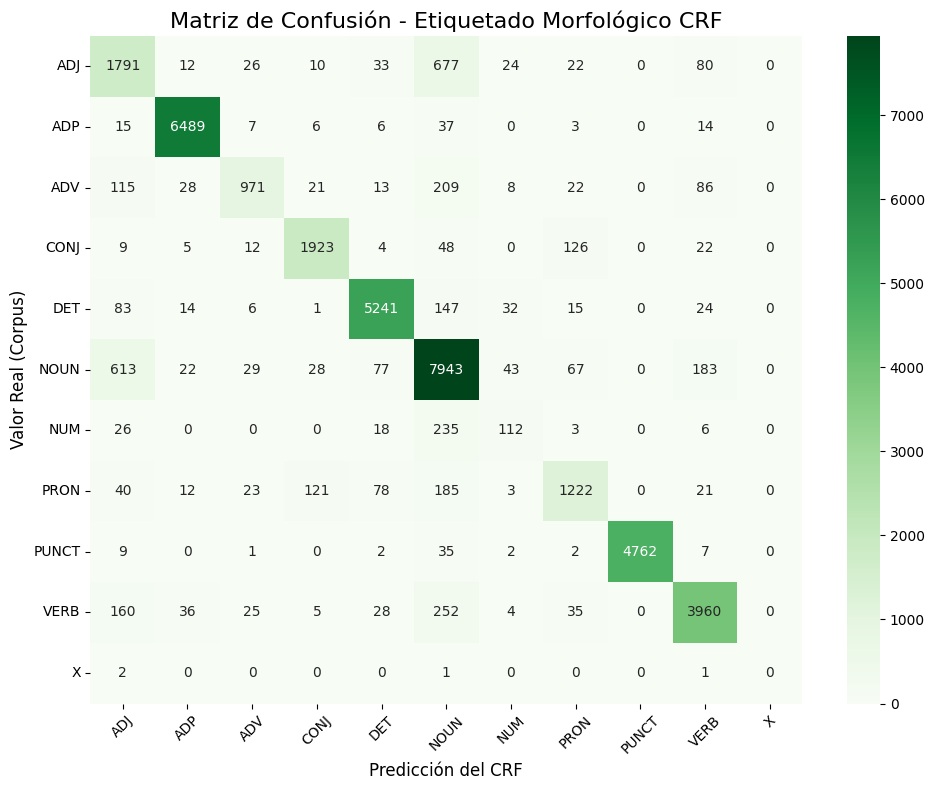

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Obtenemos la lista de etiquetas únicas en el archivo test.
labels = sorted(set(y_test_flat))

# Creamos la matriz de confusión
cm = confusion_matrix(y_test_flat, y_pred_flat, labels=labels)

# Graficamos con las bibliotecas para graficar.

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,       
    fmt='d',         
    cmap='Greens',     
    xticklabels=labels,  
    yticklabels=labels   
)

plt.title('Matriz de Confusión - Etiquetado Morfológico CRF', fontsize=16)
plt.xlabel('Predicción del CRF', fontsize=12)
plt.ylabel('Valor Real (Corpus)', fontsize=12)
plt.xticks(rotation=45) 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


A partir de la matriz de confusión podemos observar que, en general, el modelo CRF funciona adecuadamente. No se presentan casos extremadamente problemáticos en los que el sistema falle de manera masiva. Sin embargo, aunque los valores de la diagonal son aceptables, existen algunas categorías en las que el sistema comete más errores que en otras. Esto ocurre especialmente cuando debe etiquetar adjetivos, adverbios, números y pronombres, donde el desempeño es menor que en el caso de los sustantivos.

En particular, se puede observar que, cuando el sistema se equivoca, tiende a etiquetar como sustantivos palabras que no lo son, o bien a etiquetar sustantivos como otras categorías gramaticales. Este fenómeno ocurre principalmente entre adjetivos y sustantivos, que son las celdas donde se concentran la mayoría de los errores. Esto podría deberse a fenómenos de ambigüedad léxica, ya que en español existen procesos como la sustantivización, mediante los cuales un adjetivo, verbo o adverbio puede utilizarse con función sustantiva.

Para reducir este tipo de errores, sería conveniente mejorar el entrenamiento del sistema, por ejemplo incorporando características o pesos que permitan modelar con mayor precisión los contextos en los que ocurre la sustantivización.

Asimismo, considerando cómo se adquiere y procesa el lenguaje en el aprendizaje de idiomas, podría resultar útil que el sistema amplíe el contexto considerado para cada palabra, tomando en cuenta las palabras cercanas. El lenguaje no siempre se interpreta únicamente a partir del significado individual de cada palabra, sino también de la manera en que estas interactúan dentro de su contexto.